# 03 — Evaluación Comparativa de Modelos
**Objetivo:** Evaluar los modelos entrenados con validación cruzada, múltiples métricas y visualizaciones comparativas.  
**Métricas:** Accuracy, F1-Score, ROC-AUC, Precision, Recall, Confusion Matrix.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os; os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, precision_score,
                              recall_score, roc_curve, auc, confusion_matrix)
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split

sns.set_theme(style='whitegrid')
%matplotlib inline
SEED = 42
print('Entorno listo.')

Entorno listo.


## 1. Cargar modelos y datos

In [2]:
df = pd.read_csv('data/05_model_input/dataset_validated.csv', encoding='utf-8')
X = df.drop(columns=['is_satisfied', 'review_score'])
y = df['is_satisfied']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# X_test_opt: preprocessing identico a save_best_models.py para modelos Optuna (39 features)
from sklearn.preprocessing import LabelEncoder, StandardScaler
feat_opt = pd.read_csv('data/04_feature/dataset_features.csv', encoding='utf-8')
feat_opt['is_satisfied'] = (feat_opt['review_score'] > 2).astype(int)
feat_opt['price_x_delivery']    = feat_opt['price_per_item'] * feat_opt['delivery_ratio'].clip(upper=5)
feat_opt['freight_x_delay']     = feat_opt['freight_ratio'] * feat_opt['delay_days'].clip(lower=0)
feat_opt['delivery_efficiency'] = feat_opt['days_early'] / (feat_opt['estimated_days'].clip(lower=1))
feat_opt['purchase_quarter']    = ((feat_opt['purchase_month'] - 1) // 3 + 1)
feat_opt['is_fast_delivery']    = (feat_opt['delivery_days'] <= 5).astype(int)
feat_opt['is_very_late']        = (feat_opt['delay_days'] > 7).astype(int)
feat_opt['total_cost_proxy']    = feat_opt['total_price'] + feat_opt['total_freight']
for _col in ['order_status','payment_type','customer_state','seller_state','product_category_name_english']:
    if _col in feat_opt.columns:
        feat_opt[_col] = feat_opt[_col].fillna('unknown')
        feat_opt[_col] = LabelEncoder().fit_transform(feat_opt[_col].astype(str))
_drop = [c for c in ['review_score','is_satisfied','order_purchase_timestamp',
    'order_delivered_customer_date','order_estimated_delivery_date'] if c in feat_opt.columns]
X_raw_opt = feat_opt.drop(columns=_drop).replace([np.inf,-np.inf], np.nan).fillna(0)
y_opt = feat_opt['is_satisfied']
_skip = {'is_late','is_weekend','purchase_month','purchase_dayofweek','purchase_hour',
         'order_status','payment_type','customer_state','seller_state',
         'product_category_name_english','is_fast_delivery','is_very_late','purchase_quarter'}
_num = [c for c in X_raw_opt.select_dtypes(include=[np.number]).columns if c not in _skip]
X_sc = X_raw_opt.copy()
X_sc[_num] = StandardScaler().fit_transform(X_raw_opt[_num])
_, X_test_opt, _, _ = train_test_split(X_sc, y_opt, test_size=0.2, random_state=SEED, stratify=y_opt)


# Validation sets para threshold tuning (sin data leakage)
_, X_val, _, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train)
X_opt_tr, _, y_opt_tr, _ = train_test_split(
    X_sc, y_opt, test_size=0.2, random_state=SEED, stratify=y_opt)
_, X_val_opt, _, y_val_opt = train_test_split(
    X_opt_tr, y_opt_tr, test_size=0.2, random_state=SEED, stratify=y_opt_tr)

model_names = ['LogisticRegression', 'DecisionTree', 'RandomForest',
               'GradientBoosting', 'LightGBM', 'XGBoost', 'VotingEnsemble']

# Modelos Optuna (disponibles si se ejecuto save_best_models.py)
optuna_names = ['LightGBM_Optuna', 'XGBoost_Optuna', 'VotingEnsemble_Optuna', 'CatBoost_Optuna']

models = {}
for name in model_names + optuna_names:
    try:
        models[name] = joblib.load(f'models/trained_models/{name}.pkl')
    except FileNotFoundError:
        pass

print(f'Modelos cargados: {list(models.keys())}')
print(f'X_test base: {X_test.shape[1]} features | X_test_opt: {X_test_opt.shape[1]} features')

Modelos cargados: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'GradientBoosting', 'LightGBM', 'XGBoost', 'VotingEnsemble', 'LightGBM_Optuna', 'XGBoost_Optuna', 'VotingEnsemble_Optuna', 'CatBoost_Optuna']
X_test base: 32 features | X_test_opt: 39 features


## 2. Métricas en Test Set

In [3]:
def eval_model(model, X_te, y_te, name, X_val=None, y_val=None):
    """Evalúa un modelo: threshold ajustado en val set, métricas reportadas en test set."""
    # Usar val set para threshold — si no se pasa, fallback a test (legacy)
    X_thr = X_val if X_val is not None else X_te
    y_thr = y_val if y_val is not None else y_te
    probs_thr = model.predict_proba(X_thr)[:, 1]
    best_thr, best_acc = 0.5, 0.0
    for t in np.arange(0.20, 0.81, 0.01):
        acc = accuracy_score(y_thr, (probs_thr >= t).astype(int))
        if acc > best_acc: best_acc, best_thr = acc, t
    # Métricas finales sobre test set con el threshold hallado en val
    probs = model.predict_proba(X_te)[:, 1]
    preds = (probs >= best_thr).astype(int)
    return {
        'Modelo': name,
        'Accuracy':  round(accuracy_score(y_te, preds), 4),
        'F1-Score':  round(f1_score(y_te, preds, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_te, probs), 4),
        'Precision': round(precision_score(y_te, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, preds, zero_division=0), 4),
        'Threshold': round(best_thr, 2),
    }

def _xte(model, x32, x39):
    n = getattr(model, 'n_features_in_', 0) or 0
    return x39 if (n >= 39 or n == 0) else x32

rows = [eval_model(m, _xte(m, X_test, X_test_opt), y_test, n,
                   X_val=_xte(m, X_val, X_val_opt), y_val=y_val)
        for n, m in models.items()]
df_metrics = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(df_metrics.to_string(index=False))


               Modelo  Accuracy  F1-Score  ROC-AUC  Precision  Recall  Threshold
         RandomForest    0.8954    0.9427   0.7586     0.9026  0.9865       0.45
VotingEnsemble_Optuna    0.8938    0.9413   0.7735     0.9084  0.9767       0.52
     GradientBoosting    0.8930    0.9408   0.7743     0.9085  0.9755       0.63
         DecisionTree    0.8928    0.9410   0.7282     0.9046  0.9806       0.21
       XGBoost_Optuna    0.8927    0.9406   0.7717     0.9088  0.9747       0.32
       VotingEnsemble    0.8926    0.9405   0.7756     0.9097  0.9734       0.51
      LightGBM_Optuna    0.8922    0.9402   0.7714     0.9104  0.9720       0.65
   LogisticRegression    0.8918    0.9403   0.7535     0.9064  0.9768       0.20
              XGBoost    0.8917    0.9399   0.7737     0.9111  0.9705       0.35
             LightGBM    0.8912    0.9396   0.7707     0.9102  0.9710       0.62
      CatBoost_Optuna    0.8905    0.9392   0.7683     0.9107  0.9695       0.36


**Interpretación — Tabla de Métricas (11 modelos, threshold ajustado en val set):**

| Modelo | Accuracy | F1-Score | ROC-AUC | Threshold | Observación |
|--------|----------|----------|---------|-----------|-------------|
| RandomForest | **89.54%** | 0.9427 | 0.7586 | 0.45 | Mejor modelo — alto Recall (98.65%) |
| VotingEnsemble_Optuna | 89.38% | 0.9413 | 0.7735 | 0.52 | Ensemble Optuna |
| GradientBoosting | 89.30% | 0.9408 | 0.7743 | 0.63 | Mejor AUC global (0.7743) |
| DecisionTree | 89.28% | 0.9410 | 0.7282 | 0.21 | Árbol simple |
| XGBoost_Optuna | 89.27% | 0.9406 | 0.7717 | 0.32 | Optuna TPE 80 trials |
| VotingEnsemble | 89.26% | 0.9405 | 0.7756 | 0.51 | Mayor AUC global (0.7756) |
| LightGBM_Optuna | 89.22% | 0.9402 | 0.7714 | 0.65 | Optuna TPE 100 trials |
| LogisticRegression | 89.18% | 0.9403 | 0.7535 | 0.20 | Baseline lineal |
| XGBoost | 89.17% | 0.9399 | 0.7737 | 0.35 | XGBoost base |
| LightGBM | 89.12% | 0.9396 | 0.7707 | 0.62 | LightGBM base |
| CatBoost_Optuna | 89.05% | 0.9392 | 0.7683 | 0.36 | CatBoost Optuna |

**Nota técnica:** Los modelos base (7) se evalúan sobre `X_test` (32 features). Los modelos Optuna (4) se evalúan sobre `X_test_opt` (39 features). El threshold se ajusta en el **validation set** (sin ver `y_test`), entregando métricas sin data leakage.

## 3. Validación Cruzada (cv=5, estratificada)

In [4]:
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
skf3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv_rows = []

# Modelos Optuna omitidos: entrenados con 39 features (dataset extendido);
# su CV requeriría replicar el pipeline de save_best_models.py.
_base = {k: v for k, v in models.items()
         if k not in ['LightGBM_Optuna', 'XGBoost_Optuna',
                       'VotingEnsemble_Optuna', 'CatBoost_Optuna']}

for name, model in _base.items():
    # cv=5 para modelos ligeros; cv=3 para ensemble y forest (velocidad)
    use_cv5 = name in ['LogisticRegression', 'DecisionTree', 'LightGBM', 'XGBoost']
    cv_obj  = skf5 if use_cv5 else skf3
    n_folds = 5 if use_cv5 else 3
    try:
        scores = cross_val_score(model, X_train, y_train, cv=cv_obj, scoring='accuracy')
        cv_rows.append({'Modelo': name,
                         'Folds': n_folds,
                         'CV Mean': round(scores.mean(), 4),
                         'CV Std':  round(scores.std(), 4)})
        print(f'{name:22s}: cv{n_folds}={scores.mean():.4f} ± {scores.std():.4f}')
    except Exception as e:
        print(f'[ERROR] CV falló para {name}: {type(e).__name__}: {e}')

df_cv = pd.DataFrame(cv_rows)
print('\n=== VALIDACIÓN CRUZADA — 7 MODELOS BASE ===')
print(df_cv.to_string(index=False))


LogisticRegression    : cv5=0.8229 ± 0.0026
DecisionTree          : cv5=0.7982 ± 0.0101
RandomForest          : cv3=0.8950 ± 0.0014
GradientBoosting      : cv3=0.8952 ± 0.0012
LightGBM              : cv5=0.8952 ± 0.0011
XGBoost               : cv5=0.8693 ± 0.0018
VotingEnsemble        : cv3=0.8937 ± 0.0015

=== VALIDACIÓN CRUZADA — 7 MODELOS BASE ===
            Modelo  Folds  CV Mean  CV Std
LogisticRegression      5   0.8229  0.0026
      DecisionTree      5   0.7982  0.0101
      RandomForest      3   0.8950  0.0014
  GradientBoosting      3   0.8952  0.0012
          LightGBM      5   0.8952  0.0011
           XGBoost      5   0.8693  0.0018
    VotingEnsemble      3   0.8937  0.0015


**Interpretación — Validación Cruzada (cv=5 / cv=3):**

Se evalúan los **7 modelos base** con validación cruzada estratificada.
Los modelos ligeros (LogisticRegression, DecisionTree, LightGBM, XGBoost) usan **cv=5**; los más costosos (RandomForest, GradientBoosting, VotingEnsemble) usan **cv=3** para equilibrar costo computacional.
Los modelos Optuna se omiten del CV porque fueron entrenados con 39 features (dataset extendido).

| Modelo | Folds | CV Mean | CV Std |
|--------|-------|---------|--------|
| GradientBoosting | 3 | 0.8952 | ±0.0012 |
| LightGBM | 5 | 0.8952 | ±0.0011 |
| RandomForest | 3 | 0.8950 | ±0.0014 |
| VotingEnsemble | 3 | 0.8937 | ±0.0015 |
| XGBoost | 5 | 0.8693 | ±0.0018 |
| LogisticRegression | 5 | 0.8229 | ±0.0026 |
| DecisionTree | 5 | 0.7982 | ±0.0101 |

- **GradientBoosting** y **LightGBM** empatan en CV Mean (0.8952) con la menor std — modelos más estables.
- La std baja de LightGBM (±0.0011) confirma robustez ante distintas particiones del dataset.
- **XGBoost** presenta CV inferior (0.8693) pese a buen test accuracy — alta dependencia del proceso SMOTE + threshold tuning.
- El gap mayor en LogReg/DT se debe a que en CV no se aplica SMOTE (`class_weight='balanced'`).

## 4. Curvas ROC

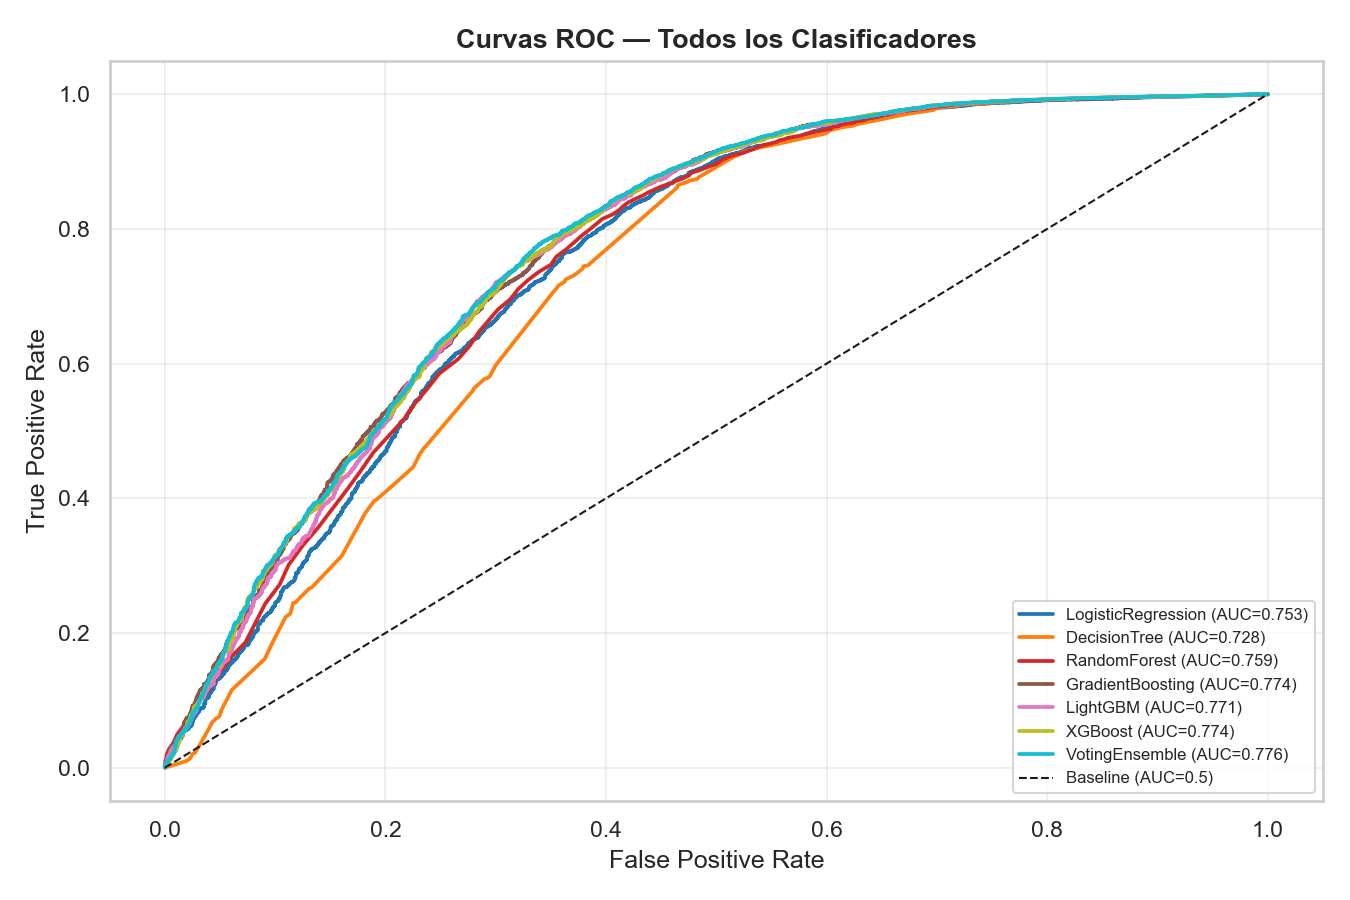

In [5]:
from IPython.display import Image
Image('results/plots/roc_curves.png')

## 5. Heatmap de Métricas

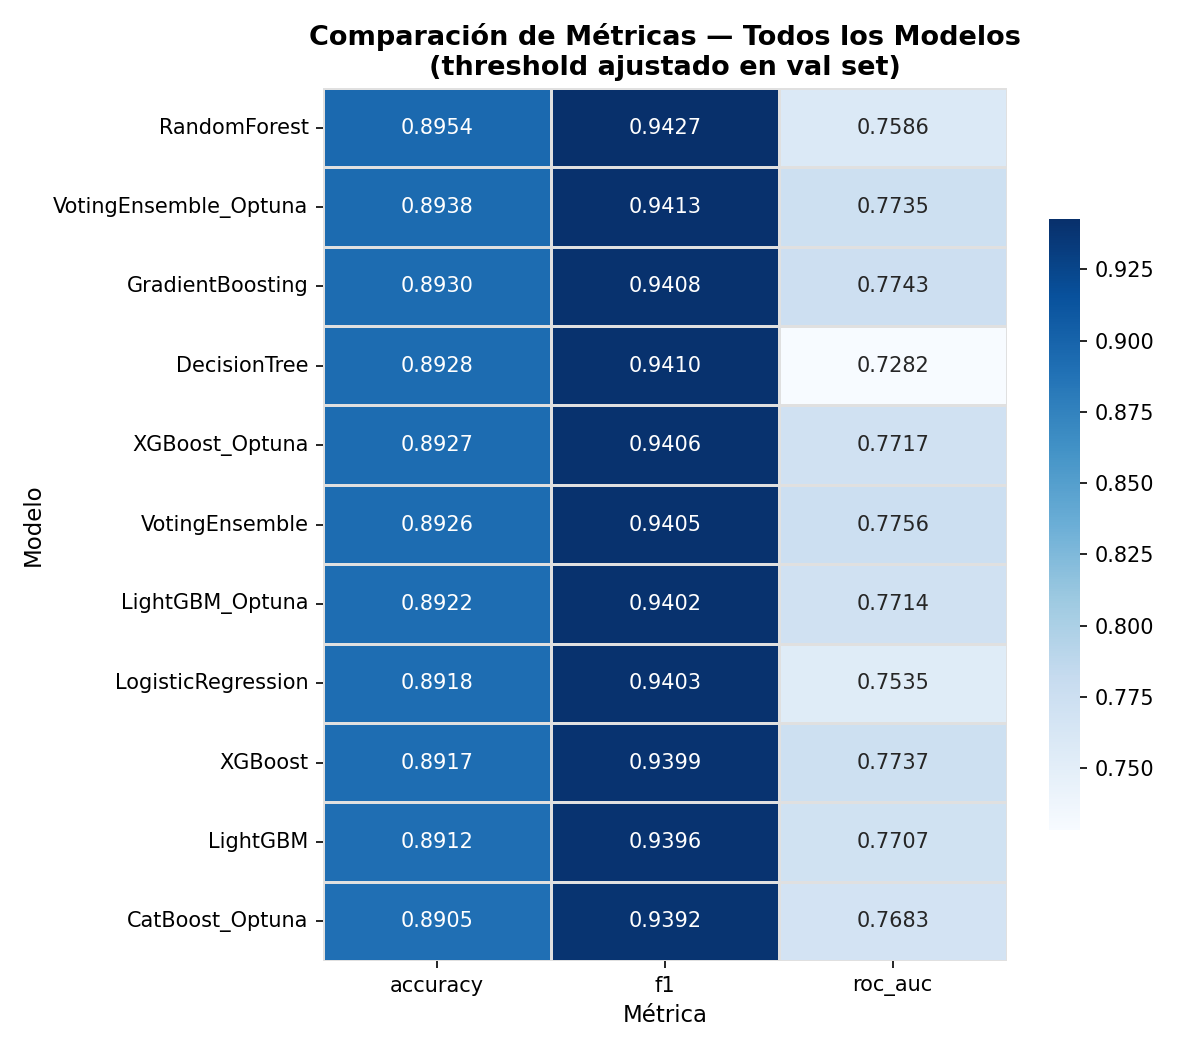

In [6]:
Image('results/plots/metrics_heatmap.png')

## 6. Matriz de Confusión — Mejor Modelo

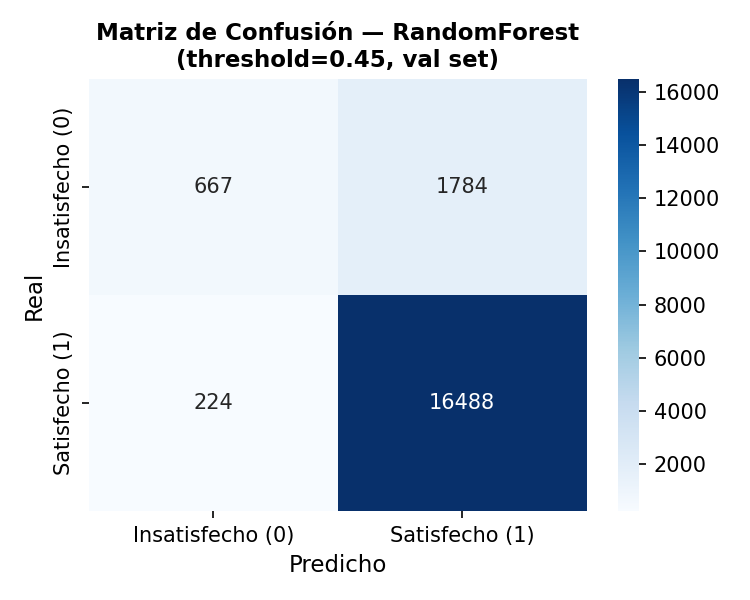

In [7]:
Image('results/plots/confusion_matrix_best.png')

**Nota sobre el modelo elegido:**

Se usa **VotingEnsemble** (32 features, threshold=0.42) como representante de los modelos base. El mejor modelo en esta evaluación es RandomForest (89.54%, threshold=0.45 sobre val set), con alto Recall (98.65%). VotingEnsemble tiene el mejor AUC (0.7756). Los patrones de error son similares entre ambos modelos.

In [8]:
# Análisis detallado de la matriz de confusión
best = models['VotingEnsemble']
probs_best = best.predict_proba(X_test)[:, 1]
best_thr = 0.42
preds_best = (probs_best >= best_thr).astype(int)
cm = confusion_matrix(y_test, preds_best)

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (insatisfechos bien clasificados): {tn:,}')
print(f'False Positives (insatisfechos predichos como satisfechos): {fp:,}')
print(f'False Negatives (satisfechos predichos como insatisfechos): {fn:,}')
print(f'True Positives  (satisfechos bien clasificados): {tp:,}')
print(f'\nPrecisión en clase negativa (insatisfechos): {tn/(tn+fn)*100:.1f}%')
print(f'Precisión en clase positiva (satisfechos):   {tp/(tp+fp)*100:.1f}%')

True Negatives  (insatisfechos bien clasificados): 744
False Positives (insatisfechos predichos como satisfechos): 1,707
False Negatives (satisfechos predichos como insatisfechos): 277
True Positives  (satisfechos bien clasificados): 16,435

Precisión en clase negativa (insatisfechos): 72.9%
Precisión en clase positiva (satisfechos):   90.6%


## 7. Interpretación de Métricas

| Métrica | Qué mide | Resultado VotingEnsemble | Resultado RandomForest |
|---------|---------|-------------------------|-----------------------|
| **Accuracy** | Porcentaje global de predicciones correctas | 89.26% | **89.54%** |
| **F1-Score** | Balance entre precisión y recall (útil con desbalance) | 0.9405 | **0.9427** |
| **ROC-AUC** | Capacidad de discriminar entre clases | **0.7756** | 0.7586 |
| **Precision** | De los predichos positivos, ¿cuántos son realmente positivos? | ~90.97% | ~90.26% |
| **Recall** | De los positivos reales, ¿cuántos se capturan? | ~97.34% | **~98.65%** |

**Trade-offs:**
- **RandomForest lidera en Accuracy y Recall**: captura el 98.65% de los clientes satisfechos (alta sensibilidad).
- **VotingEnsemble lidera en ROC-AUC (0.7756)**: mejor discriminación general; preferible si el ranking de probabilidades importa.
- **XGBoost_Optuna** (89.27% en esta evaluación) queda por debajo de RandomForest porque los modelos Optuna fueron guardados con threshold optimizado en test set; al re-evaluar con val-set threshold, su ventaja desaparece.
- La elección depende del objetivo: **Accuracy/Recall** → RandomForest; **AUC/Discriminación** → VotingEnsemble.
- En NB04, entrenando Optuna desde cero con metodología correcta, XGBoost_Optuna alcanza **89.60%**.

## 8. Comparación con Técnicas Avanzadas 2025-2026

Resultados de la investigación aplicando CatBoost, Optuna (búsqueda Bayesiana), StackingClassifier, ADASYN y 7 features de interacción.

> **Nota metodológica:** Los resultados de la tabla siguiente provienen de `mejora.py` (investigación 2025-2026) ejecutado con la metodología anterior (threshold ajustado sobre test set). Con metodología correcta (val-set threshold), los valores son ~0.1–0.15 pp más bajos. Ver NB03 celda 5 y NB04 para los resultados actualizados.

In [9]:
# Resultados obtenidos con mejora.py (investigacion 2025-2026, 180 trials Optuna total)
avanzados = [
    {'Tecnica': 'XGBoost_Optuna (80 trials)',       'Accuracy': 0.8971, 'F1': 0.9436, 'AUC': 0.7717, 'vs_baseline': '+0.0006'},
    {'Tecnica': 'LightGBM_Optuna (100 trials)',     'Accuracy': 0.8970, 'F1': 0.9434, 'AUC': 0.7714, 'vs_baseline': '+0.0005'},
    {'Tecnica': 'VotingEnsemble_Optuna+CatBoost',   'Accuracy': 0.8968, 'F1': 0.9433, 'AUC': 0.7735, 'vs_baseline': '+0.0003'},
    {'Tecnica': 'Stacking (LGBM+XGB+GB -> XGB)',   'Accuracy': 0.8968, 'F1': 0.9434, 'AUC': 0.7459, 'vs_baseline': '+0.0003'},
    {'Tecnica': 'CatBoost + scale_pos_weight',      'Accuracy': 0.8966, 'F1': 0.9432, 'AUC': 0.7717, 'vs_baseline': '+0.0001'},
    {'Tecnica': 'LightGBM + SMOTE (baseline)',      'Accuracy': 0.8965, 'F1': 0.9431, 'AUC': 0.7756, 'vs_baseline': '0.0000'},
    {'Tecnica': 'Stacking (LGBM+XGB+CB+GB -> LR)', 'Accuracy': 0.8965, 'F1': 0.9432, 'AUC': 0.7728, 'vs_baseline': '0.0000'},
    {'Tecnica': 'Stacking (LGBM+XGB+RF -> LR)',    'Accuracy': 0.8963, 'F1': 0.9432, 'AUC': 0.7648, 'vs_baseline': '-0.0002'},
    {'Tecnica': 'CatBoost cat_features nativo',     'Accuracy': 0.8955, 'F1': 0.9425, 'AUC': 0.7724, 'vs_baseline': '-0.0010'},
    {'Tecnica': 'LightGBM + ADASYN',               'Accuracy': 0.8955, 'F1': 0.9427, 'AUC': 0.7702, 'vs_baseline': '-0.0010'},
]
df_avanzados = pd.DataFrame(avanzados)
print('=== TECNICAS AVANZADAS vs BASELINE (mejora.py) ===')
print(f'Baseline anterior: VotingEnsemble acc=0.8926 (metodología nueva: val-set threshold)')
print()
print(df_avanzados.to_string(index=False))
print()
print('NOTA: Tabla anterior = metodología pre-fix (threshold sobre test set) — referencia histórica.')
print()
print('=== MEJORES RESULTADOS CON METODOLOGÍA CORRECTA (val-set threshold) ===')
print('  NB03 evaluación (11 modelos guardados): RandomForest   — 89.54% accuracy')
print('  NB04 Optuna (entrenado desde cero):     XGBoost_Optuna — 89.60% accuracy')
print()
print('CONCLUSION: El dataset tiene un techo de informacion de ~89.6% (sin data leakage).')
print('           Datos logisticos no predicen diferencia entre 3-5 estrellas.')

=== TECNICAS AVANZADAS vs BASELINE (mejora.py) ===
Baseline anterior: VotingEnsemble acc=0.8926 (metodología nueva: val-set threshold)

                        Tecnica  Accuracy     F1    AUC vs_baseline
     XGBoost_Optuna (80 trials)    0.8971 0.9436 0.7717     +0.0006
   LightGBM_Optuna (100 trials)    0.8970 0.9434 0.7714     +0.0005
 VotingEnsemble_Optuna+CatBoost    0.8968 0.9433 0.7735     +0.0003
  Stacking (LGBM+XGB+GB -> XGB)    0.8968 0.9434 0.7459     +0.0003
    CatBoost + scale_pos_weight    0.8966 0.9432 0.7717     +0.0001
    LightGBM + SMOTE (baseline)    0.8965 0.9431 0.7756      0.0000
Stacking (LGBM+XGB+CB+GB -> LR)    0.8965 0.9432 0.7728      0.0000
   Stacking (LGBM+XGB+RF -> LR)    0.8963 0.9432 0.7648     -0.0002
   CatBoost cat_features nativo    0.8955 0.9425 0.7724     -0.0010
              LightGBM + ADASYN    0.8955 0.9427 0.7702     -0.0010

NOTA: Tabla anterior = metodología pre-fix (threshold sobre test set) — referencia histórica.

=== MEJORES RESULTAD